# Chapter 8. Unsupervised Learning Techniques

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

***Clustering***: the goal is to group similar instances together into clusters. Clustering is a great tool for data analysis, customer segmentation, recommender systems, search engines, image segmentation, semi-supervised learning, dimensionality reduction, and more.
<br>

***Anomaly detection (aka outlier detection)***: the goal is to learn what "normal" data looks like, and then use that to detect abnormal instances. These instances are called *anomalies* or *outliers*, while the normal instances are called *inliers*. Anomaly detection is useful in a wide variety of applications, such as fraud detection, detecting defective products in manufacturing, identifying new trends in time series, or removing outliers from a dataset before training another model, which can significantly improve the performance of the resulting model.
<br>

***Density estimation***: the goal is to estimate the *probability density function (PDF)* of the random process that generated the dataset. Density estimation is commonly used for anomaly detection: instances located in very low-density regions are likely to be anomalies. It is also useful for data analysis and visualization.

## 1. Clustering Algorithms: k-means and DBSCAN

### 1.1. k-Means Clustering

#### 1.1.1. The k-means algorithm

***K-Means Clustering*** starts by placing the centroids randomly (e.g., by picking k instances at random from the dataset and using their locations as centroids). Then label the instances by assigning each to the cluster whose centroid is closest -> update the centroid by computing the mean of the instances in each cluster -> label the instance -> update the centroid -> so on -> untill the centroids stop moving. The algorithm is guaranteed to converge in a finite number of steps (usually quite small), because the mean squared distance between the instances and their closest centroids can only go down at each step, and since it cannot be negative, it is guaranteed to converge.

<br>

Though guaranteed to converge, it may not converge to the right solution: whether it does or not depends on the **centroid initialization**.

The computational complexity of the algorithm is generally linear with regard to 
- the number of instances m,
- the number of clusters k,
- the number of dimensions n.
<br>

However, this is only true with the data has a clustering structure. If it does not, then in the worst-case scenario, the complexity can increase exponentially with the number of instances. In practice, this rarely happens, and k-means is generally one of the fatest clustering algorithms.

In [2]:
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, 
                  cluster_std=blob_std, random_state=7)

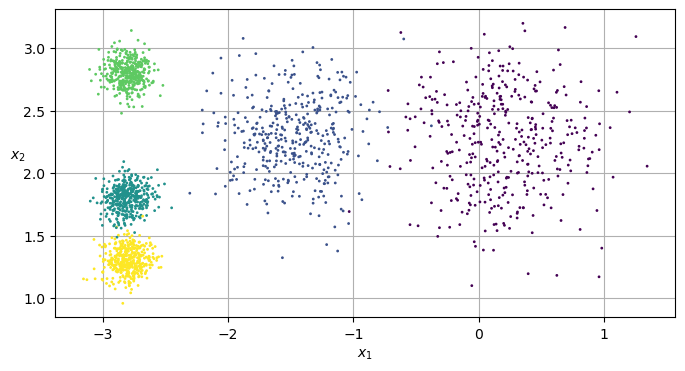

In [ ]:
def plot_clusters(X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X, y)
plt.gca().set_axisbelow(True)
plt.grid()

plt.show()

**Note, we have to specify the number of clusters k that the algorithm must find.**

In [3]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=43)
y_pred = kmeans.fit_predict(X)

In [4]:
np.unique(y_pred)

array([0, 1, 2, 3, 4], dtype=int32)

In [8]:
kmeans.cluster_centers_.round(2)

array([[-2.8 ,  1.8 ],
       [ 0.21,  2.26],
       [-2.79,  2.8 ],
       [-1.47,  2.29],
       [-2.8 ,  1.3 ]])

We can easily assign new instances to the cluster whose centroid is closet:

In [6]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([1, 1, 2, 2], dtype=int32)

K-means works well when clusters are roughly spherical, similar in size, and well separated. **It performs poorly when clusters have very different diameters** because it assigns each point based only on the distance to the nearest centroid.

Instead of assigning each instance to a single cluster, which is called ***hard clustering***, it can be useful to give each instance a score per cluster, which is called ***soft clustering***. The score can be the distance between the instance and the centroid or a similarity score (or affinity), such as the Gaussian radial basis function.
- Can be a very efficient nonlinear dimensionality reduction technique if we have a high dimensional data.
- We can also use these distances as extra features to train another model.

In [7]:
kmeans.transform(X_new).round(2)

array([[2.81, 0.33, 2.9 , 1.49, 2.89],
       [5.81, 2.8 , 5.85, 4.48, 5.84],
       [1.21, 3.29, 0.29, 1.69, 1.71],
       [0.73, 3.22, 0.36, 1.55, 1.22]])

#### 1.1.2. Centroid initialization methods

One option is to run the algorithm multiple times with different random initializations and keep the best solution.
- `n_init` hyperparameter: the number of random initialization
- `init = 'random'`
<br>

The model's ***intertia***: the performance metric determines the best solution.
$$
\text{inertia} = \sum_i \left\| x^{(i)} - c^{(i)} \right\|^2
$$

In [9]:
kmeans.inertia_

211.59853725816836

The `score()` method resturns to the negative inertia (it is negative because a predictor's `score()` method must always respect Scikit-Learn's "greater is better" rule – if a predictor is better than another, its `score()` methods should return a greater score)

In [11]:
kmeans.score(X)

-211.59853725816836

***K-means++***: `int='k-means++` (default hyperparameter) is a smarter initialization step that tends to select centroids that are distant from one another, which makes the k-means algorithm much more likely to locate all important clusters, and less likely to converge to a suboptimal solution.

1. Take one centroid $c^{(1)}$, chosen uniformly at random from the dataset.

2. Take a new centroid $c^{(i)}$, choosing an instance $x^{(i)}$ with probability:

$$
\frac{D(x^{(i)})^2}{\sum_{j=1}^{m} D(x^{(j)})^2}
$$

where $D(x^{(i)})$ is the distance between the instance $x^{(i)}$ and the closest centroid that was already chosen.

This probability distribution ensures that instances farther away from already chosen centroids are much more likely to be selected as centroids.

3. Repeat the previous step until all $k$ centroids have been chosen.

When setting `init = 'k-means++'`, the `KMeans` class actually uses a variant of k-means++ called *greedy k-means++*: instead of sampling a single centroid at each iteration, it samples multiple and picks the best one. When using this algorithm, `n_init` defaults to 1.

### 1.2. Limits of k-Means

### 1.3. Using Clustering for Image Segmentation

### 1.4. Using Clustering for Semi-Supervised Learning

### 1.5. DBSCAN

### 1.6. Other Clustering Algorithms

## 2. Gaussian Mixtures